## Importieren aller Bibliotheken

In [1]:
import pypsaheat as ph
import pandas as pd
import pypsa

## Einlesen aller benötigten Daten

In [2]:
data = pd.read_excel('Uebung_01_data.xlsx', index_col='time')

### Plotten der Daten

<Axes: xlabel='time'>

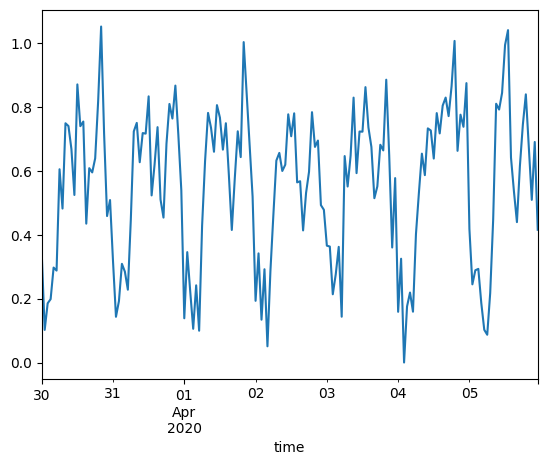

In [3]:
#Stromverbrauch allgemeiner Strom
data['electricity'].plot()

<Axes: xlabel='time'>

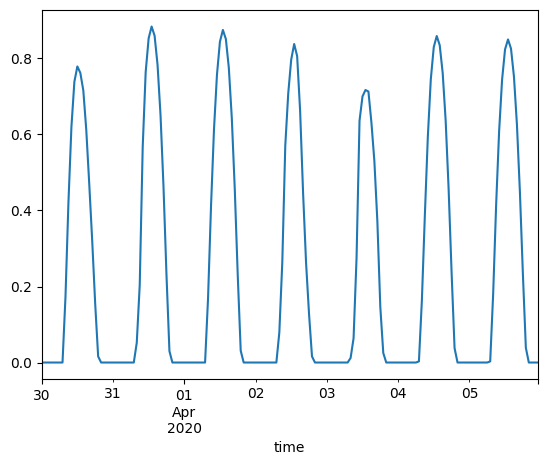

In [4]:
# PV Erzeugung
data['PV'].plot()

<Axes: xlabel='time'>

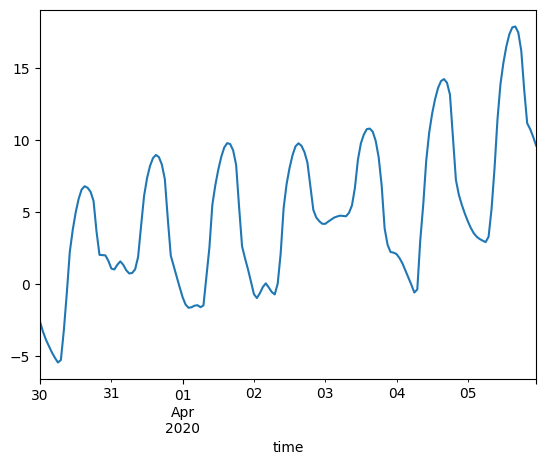

In [5]:
# Außentemperatur
data['temp'].plot()

<Axes: xlabel='time'>

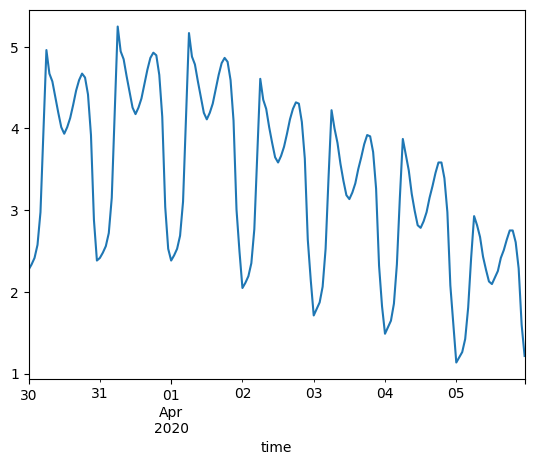

In [6]:
# Raumwärmelast
data['heat_space'].plot()

<Axes: xlabel='time'>

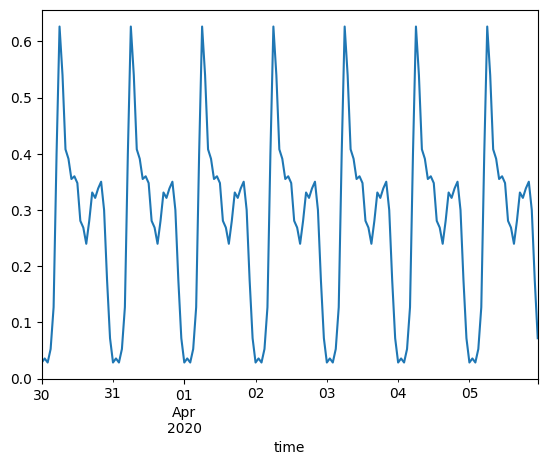

In [7]:
# Last für Warmwasser
data['heat_water'].plot()

## Aufbau eine Energiesystems

### Auslegung der Komponenten

In [8]:
#Strom
PV_power = 5 # kWp
grid_power = 15 #kW Hausanschluss Leistung
grid_cost = 0.35 # €/kWh Kosten für Netzstrombezug

#Wärme
Store_height = 1.5 #m
Store_base = 0.6 #m²
Store_T_layers = [60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50] #°C Temperaturschichten
Store_T_return = 45 #°C Rücklauftemperatur

HP_power = 6 #kW Wärmepumpenleistung
HE_power = 2 #kW Heizstableistung


### Berechnung des Vorlauftemperatur

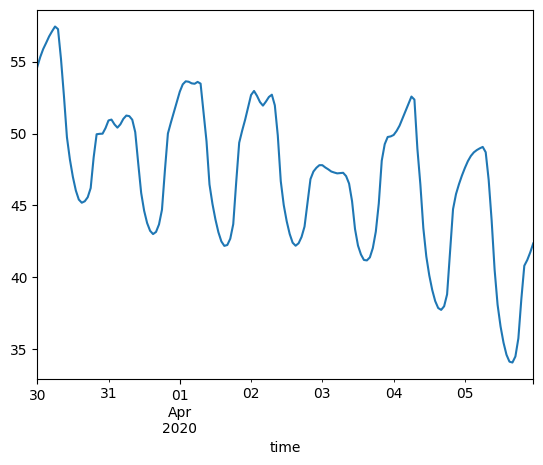

In [9]:
### Vorlauftemperatur für Heizsystem
T_at_0 = 52  #°C Vorlauftemperatur bei Außentemperatur 0°C
T_gradient = 1  #°C/°C Steigung der Heizkurve
außentemperatur = data['temp']

T_flow = ph.physics.flow_temperature(T_at_0, T_gradient, außentemperatur)
T_flow.plot()

#Anforderungstemperatur Warmwasser
T_Warmwasser = 60  #°C konstante Warmwassertemperatur

### Aufbau des Modells

In [22]:
## Ein pypsaheat Netzwerk erstellen
n = ph.HeatNetwork()

## Definieren der Simulationszeitschritte
n.set_snapshots(data.index)

###### Modellierung der elektrischen Seite ######

## Hinzufügen von Modellkomponenten
### Hinzufügen eines Knotens zur Strombilanzierung
n.add("Bus", 
      name = "electricity")
### Hinzufügen eines Generators zur Darstellung einer PV-Anlage 
n.add('Generator',
      name = 'PV',
      bus = 'electricity',
      p_nom = PV_power,
      p_max_pu = data['PV'])
### Hinzufügen eines Generators zur Darstellung des Netzbezugs
n.add('Generator',
      bus = 'electricity',
      name = 'grid',
      p_nom = grid_power,
      marginal_cost = grid_cost
      )
### Hinzufügen der elektrischen Last
n.add('Load', 
      bus = 'electricity',
      name = 'electricity_demand',
      p_set = data['electricity']
      )


###### Modellierung der Wärmeseite ######
## Hinzufügen von Modellkomponenten

#Hinzufügen eines Schichtspeichers mit konstanter Temperaturschichtung
n.add('HeatStore',
      name = 'hs',
      constant = 'temperature',
      height = Store_height, # Höhe in m
      base = Store_base, # Grundfläche in m²
      T_layer = Store_T_layers, #Temperaturschichten
      T_return = Store_T_return, #konstante Rücklauftemperatur
      cyclic = True,
      U_wall = 0
      )

#Hinzufügen einer Wärmepumpe an den Wärmespeicher
n.add('HeatPump',
      name = 'hp',
      bus0 = 'electricity',
      p_nom = HP_power, # thermische Nennleistung in kW
      heat_store = 'hs',
      T_source = data['temp'],
      T_max = 65,
      heat_source  = 'air'
      )

#Hinzufügen eines Heizstabes an den Wärmespeicher
n.add('HeatingElement',
      name = 'he',
      bus0 = 'electricity',
      p_nom = HE_power, # elektrische Nennleistung in kW
      heat_store = 'hs'
      )

#Hinzufügen der Raumwärmelast
n.add('HeatLoad',
      name = 'heat_space_demand',
      heat_store = 'hs',
      p_set = data['heat_space'],
      T_demand = T_flow
      )

#Hinzufügen der Warmwasserlast
n.add('HeatLoad',
      name = 'heat_water_demand',
      heat_store = 'hs',
      p_set = data['heat_water'],
      T_demand = T_Warmwasser
      )


c:\Users\bkoeppch\Documents\emm_project\.venv\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

c:\Users\bkoeppch\Documents\emm_project\.venv\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

c:\Users\bkoeppch\Documents\emm_project\.venv\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer 

<Axes: xlabel='time'>

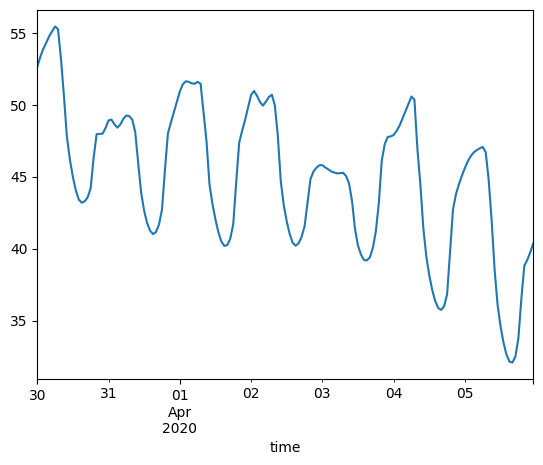

In [23]:
ph.physics.flow_temperature(50, 1, data['temp']).plot()

In [24]:
n.optimize(solver_name = 'gurobi')

Index(['electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver


Set parameter Username


INFO:gurobipy:Set parameter Username


Academic license - for non-commercial use only - expires 2026-08-27


INFO:gurobipy:Academic license - for non-commercial use only - expires 2026-08-27
INFO:linopy.io: Writing time: 0.32s


...

Solved in 2972 iterations and 0.17 seconds (0.05 work units)


INFO:gurobipy:Solved in 2972 iterations and 0.17 seconds (0.05 work units)


Optimal objective  5.152796953e+01


INFO:gurobipy:Optimal objective  5.152796953e+01
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 6048 primals, 10920 duals
Objective: 5.15e+01
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, HeatStore-hs-fix-volume-upper, HeatStore-hs-fix-volume-lower, HeatStore-hs-layer_balance, HeatStore-hs-internal-lower, HeatingElement-he-fix-p-lower, HeatingElement-he-fix-p-upper, HeatPump-hp-fix-p-lower, HeatPump-hp-fix-p-upper, HeatPump-hp-fix-p-layer-lower, HeatPump-hp-fix-p-layer-upper were not assigned to the network.


PyPSA Heat Network
Components:
 - Bus: 1
 - Generator: 2
 - Load: 1
 - HeatLoad: 2
 - HeatPump: 1
 - HeatStore: 1
 - HeatingElement: 1
Snapshots: 168

## Ergebnisse

### Speicherschichtung 

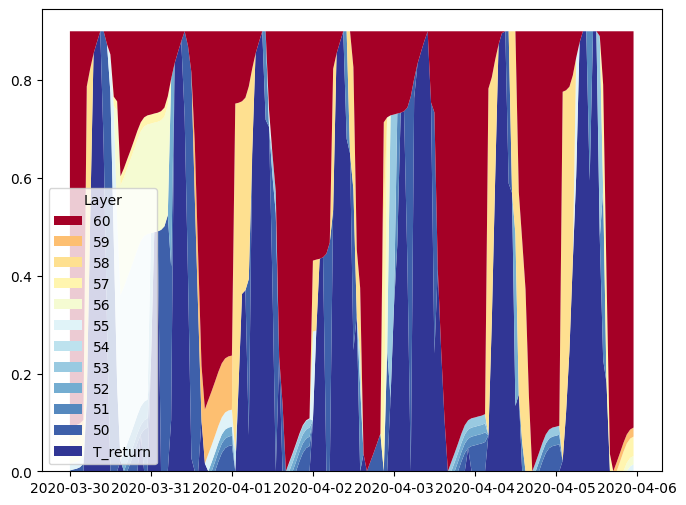

In [25]:
ph.plot.plot_stratified_heat_store(n, 'hs', sns = n.snapshots)

### Wärmelast

In [26]:
n.heat_loads_t['p_set'].sum().sum()

610.082852679208

### Wärmepumpe

In [27]:
n.heat_pumps_t['p_heat'].sum().sum()

575.9812980830757

### Heizelement 

In [28]:
n.heating_elements_t['p_heat'].sum().sum()

34.101554596095696

In [29]:
n.heating_elements_t['p_heat'].sum().sum() + n.heat_pumps_t['p_heat'].sum().sum()

610.0828526791713

### PV Erzeugung

In [65]:
PV_generation = n.generators_t.p['PV'].sum()
PV_generation

203.02499637614284

### Netzbezug

In [66]:
grid_generation = n.generators_t.p['grid'].sum()
grid_generation

148.81465650054412

### Netzbezugkosten

In [67]:
grid_costs = grid_generation * n.generators.loc['grid', 'marginal_cost']
grid_costs

52.08512977519044